---
title: "jaxcmr"
description: "JAX-accelerated toolkit for computational memory research"
---

jaxcmr is a Python library for specifying and evaluating computational models of memory search. It leverages a [compositional design](https://refactoring.guru/design-patterns/bridge) and [JAX](https://docs.jax.dev/en/latest/#)'s support for easy just-in-time compilation to streamline model prototyping and simulation so researchers can explore more ideas in less time.

## Installation

```bash
pip install jaxcmr
```

Or install the development version:

```bash
pip install git+https://github.com/githubpsyche/jaxcmr
```

## Example: Fitting CMR to Free Recall Data

Load behavioral data, fit CMR via maximum likelihood, simulate, and compare model predictions to human recall patterns.

In [10]:
import os
import warnings
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt

from jaxcmr.helpers import find_project_root, load_data, generate_trial_mask
from jaxcmr.models.cmr import make_factory
from jaxcmr.components.linear_memory import init_mfc, init_mcf
from jaxcmr.components.context import init as init_context
from jaxcmr.components.termination import NoStopTermination
from jaxcmr.fitting import ScipyDE
from jaxcmr.loss.transform_sequence_likelihood import ExcludeTerminationLikelihoodFnGenerator
from jaxcmr.simulation import simulate_h5_from_h5, simulate_study_free_recall_and_forced_stop
from jaxcmr.analyses.spc import plot_spc
from jaxcmr.analyses.crp import plot_crp
from jaxcmr.analyses.pnr import plot_pnr

warnings.filterwarnings("ignore")

In [2]:
# Load free recall data (Healey & Kahana, 2014)
data = load_data(os.path.join(find_project_root(), "data/HealeyKahana2014.h5"))
trial_mask = generate_trial_mask(data, "data['listtype'] == -1")

print(f"Loaded {trial_mask.sum()} trials from {len(jnp.unique(data['subject']))} subjects")

Loaded 3528 trials from 126 subjects


In [3]:
# Configure model and fitting
model_factory = make_factory(
    mfc_create_fn=init_mfc,
    mcf_create_fn=init_mcf,
    context_create_fn=init_context,
    termination_policy_create_fn=NoStopTermination,
)

fitter = ScipyDE(
    dataset=data,
    features=None,
    base_params={"allow_repeated_recalls": False, "learn_after_context_update": False},
    model_factory=model_factory,
    loss_fn_generator=ExcludeTerminationLikelihoodFnGenerator,
    hyperparams={
        "bounds": {
            "encoding_drift_rate": [0.0, 1.0],
            "start_drift_rate": [0.0, 1.0],
            "recall_drift_rate": [0.0, 1.0],
            "shared_support": [0.0, 100.0],
            "item_support": [0.0, 100.0],
            "learning_rate": [0.0, 1.0],
            "primacy_scale": [0.0, 100.0],
            "primacy_decay": [0.0, 100.0],
            "choice_sensitivity": [0.0, 100.0],
        },
        "num_steps": 1000,
        "pop_size": 15,
        "best_of": 1,
        "progress_bar": True,
    },
)

In [ ]:
# Fit model to each subject
results = fitter.fit_subjects(trial_mask)

In [11]:
# Simulate from fitted parameters
params = {key: jnp.array(val) for key, val in results["fits"].items()}

sim = simulate_h5_from_h5(
    model_factory, data, None, params, trial_mask,
    experiment_count=1, rng=random.PRNGKey(0), simulate_trial_fn=simulate_study_free_recall_and_forced_stop
)
sim_mask = jnp.ones(sim["recalls"].shape[0], dtype=bool)

print(f"Simulated {sim['recalls'].shape[0]} trials")

Simulated 3528 trials


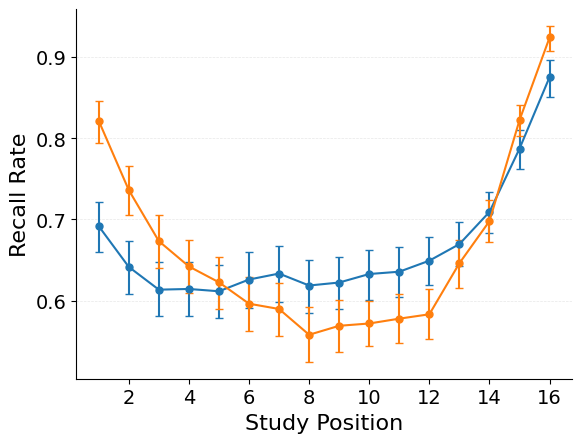

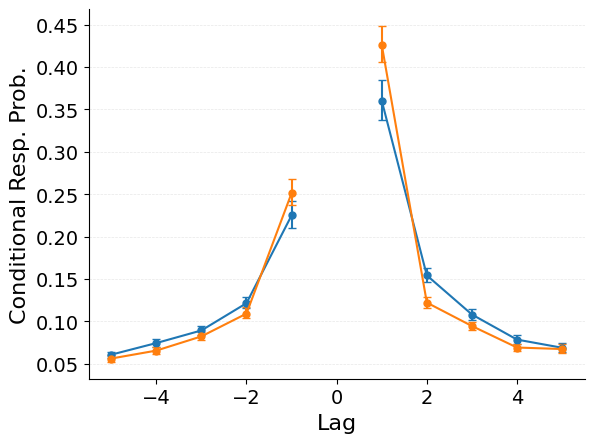

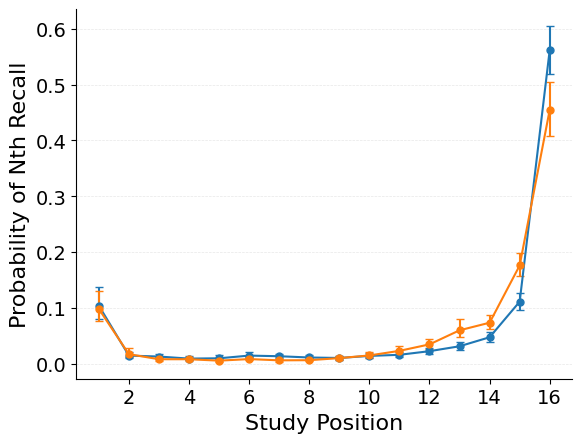

In [ ]:
#| label: figures
#| layout-ncol: 3
#| fig-cap: 
#|   - "Serial Position Curve"
#|   - "Lag-CRP"
#|   - "Probability of First Recall"

colors = ["#1f77b4", "#ff7f0e"]

plot_spc([sim, data], [sim_mask, trial_mask], color_cycle=list(colors), labels=["Model", "Data"])
plt.show()

plot_crp([sim, data], [sim_mask, trial_mask], color_cycle=list(colors), labels=["Model", "Data"])
plt.show()

plot_pnr([sim, data], [sim_mask, trial_mask], color_cycle=list(colors), labels=["Model", "Data"])
plt.show()

## Key Capabilities

- **Behavioral analyses** — SPC, CRP, PNR, and other standard measures

- **CMR model variants** — Semantic, repetition, EEG extensions

- **Model fitting** — Differential evolution with likelihood or MSE loss

- **JAX acceleration** — JIT compilation, vmap batching, explicit random state

## Why JAX?

jaxcmr uses JAX for fast, reproducible simulations:

- **JIT compilation** — Functions compile to optimized code on first call

- **vmap batching** — Vectorize across trials without writing loops

- **Explicit random state** — PRNGKey ensures reproducible results

- **PyTree models** — Model state integrates with JAX transformations

See [Why JAX](templates/guide/jax.ipynb) for details.

## Explore

::: {.grid}

::: {.g-col-12 .g-col-md-4}
### [Guide](templates/guide/index.ipynb)
Core abstractions and patterns.
:::

::: {.g-col-12 .g-col-md-4}
### [Analyses](templates/index.ipynb)
Behavioral measures for recall data.
:::

::: {.g-col-12 .g-col-md-4}
### [Models](templates/models/index.ipynb)
CMR and memory search model variants.
:::

::: {.g-col-12 .g-col-md-4}
### [Evaluation](templates/evaluation/index.ipynb)
Fitting, simulation, and model comparison.
:::

::: {.g-col-12 .g-col-md-4}
### [Workflow](templates/workflow/index.ipynb)
Research practice and tooling.
:::



::: {.g-col-12 .g-col-md-4}
### [GitHub](https://github.com/githubpsyche/jaxcmr)
Source code and issue tracker.
:::

:::